In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("job_salary_prediction_dataset1.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734


In [4]:
print(df.describe())

       experience_years   skills_count  certifications         salary
count     249398.000000  249174.000000   249425.000000  250000.000000
mean          10.006247       9.999133        2.494197  117510.722696
std            6.060365       5.463778        1.703118   38385.455248
min            0.000000       1.000000        0.000000   14139.000000
25%            5.000000       5.000000        1.000000   89666.750000
50%           10.000000      10.000000        3.000000  117504.000000
75%           15.000000      15.000000        4.000000  145491.500000
max           20.000000      19.000000        5.000000  220977.000000


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         250000 non-null  str    
 1   experience_years  249398 non-null  float64
 2   education_level   249485 non-null  str    
 3   skills_count      249174 non-null  float64
 4   industry          250000 non-null  str    
 5   company_size      249040 non-null  str    
 6   location          248931 non-null  str    
 7   remote_work       250000 non-null  str    
 8   certifications    249425 non-null  float64
 9   salary            250000 non-null  int64  
dtypes: float64(3), int64(1), str(6)
memory usage: 30.7 MB
None


In [6]:
df_copy = df.copy()

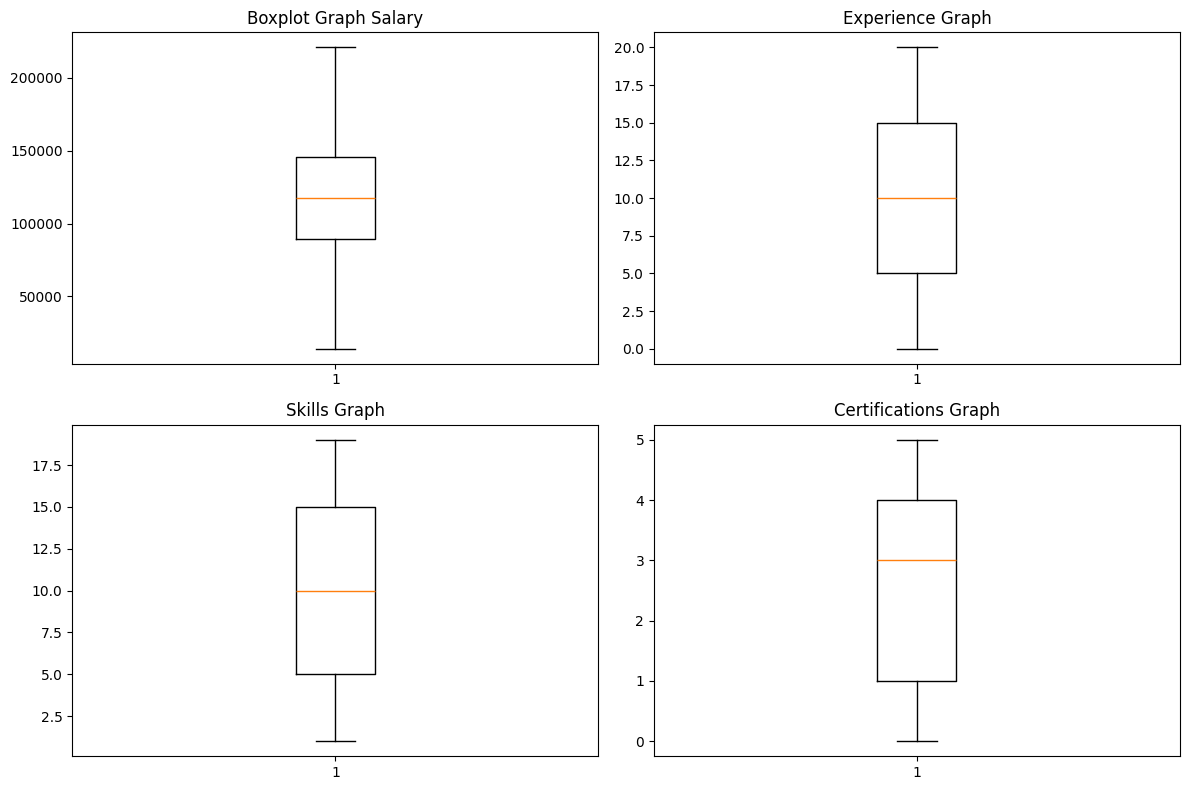

In [7]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.boxplot(df["salary"])
plt.title("Boxplot Graph Salary")
plt.subplot(2, 2, 2)
data1 = df["experience_years"].dropna()
plt.boxplot(data1)
plt.title("Experience Graph")
plt.subplot(2, 2, 3)
data2 = df["skills_count"].dropna()
plt.boxplot(data2)
plt.title("Skills Graph")
plt.subplot(2, 2, 4)
data3 = df["certifications"].dropna()
plt.boxplot(data3)
plt.title("Certifications Graph")
plt.tight_layout()
plt.show()

In [8]:
df.isnull().sum()

job_title              0
experience_years     602
education_level      515
skills_count         826
industry               0
company_size         960
location            1069
remote_work            0
certifications       575
salary                 0
dtype: int64

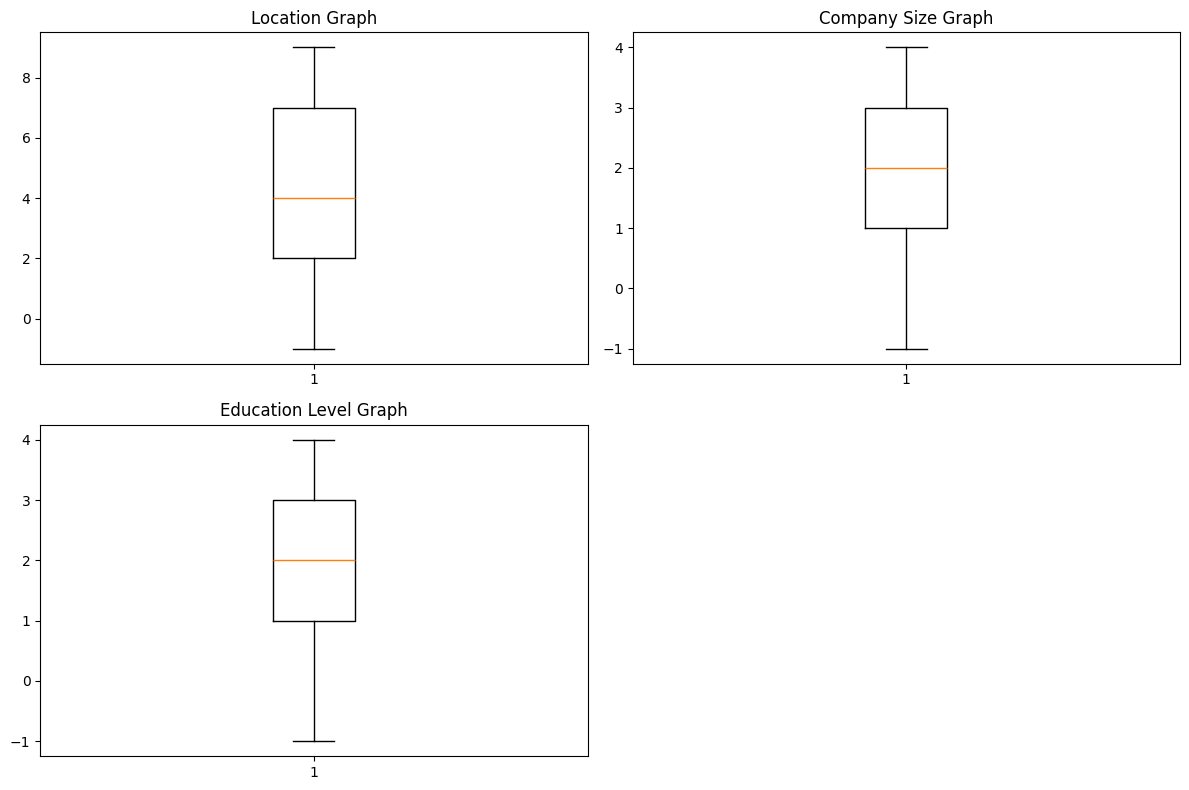

In [9]:
loc  = df["location"].astype("category").cat.codes
comp = df["company_size"].astype("category").cat.codes
edu  = df["education_level"].astype("category").cat.codes
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.boxplot(loc)
plt.title("Location Graph")
plt.subplot(2, 2, 2)
plt.boxplot(comp)
plt.title("Company Size Graph")
plt.subplot(2, 2, 3)
plt.boxplot(edu)
plt.title("Education Level Graph")
plt.tight_layout()
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.fillna({
    "experience_years": df["experience_years"].median(),
    "skills_count":     df["skills_count"].median(),
    "certifications":   df["certifications"].median()
}, inplace=True)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [12]:
df.fillna({
    "education_level": df["education_level"].mode()[0],
    "company_size":    df["company_size"].mode()[0]
}, inplace=True)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,Large,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [13]:
df.columns = df.columns.str.strip()
df["location"] = df["location"].fillna("Unknown")

In [14]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [15]:
print(df.shape)

(250000, 10)


In [16]:
print(df.columns)

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')


In [17]:
df["experience_years"] = df["experience_years"].astype(int)
df["skills_count"]     = df["skills_count"].astype(int)
df["certifications"]   = df["certifications"].astype(int)

In [18]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,85270
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,103860
2,Frontend Developer,18,PhD,4,Media,Large,Australia,No,1,126390
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,162191
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,115590
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,152738
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,69923
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,46351


In [19]:
df.columns = df.columns.str.lower()

In [20]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,85270
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,103860
2,Frontend Developer,18,PhD,4,Media,Large,Australia,No,1,126390
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,162191
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,115590
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,152738
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,69923
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,46351


In [21]:
df["education_level"] = df["education_level"].replace("PhD", "Phd")

In [22]:
for col in df.select_dtypes(include=["string", "object"]).columns:
    df[col] = df[col].str.strip()

In [23]:
df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,85270
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,103860
2,Frontend Developer,18,Phd,4,Media,Large,Australia,No,1,126390
3,Business Analyst,19,Phd,13,Retail,Medium,Canada,Yes,0,162191
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,118734
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,42265
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,119466
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,131426
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,96578
9,Frontend Developer,18,Phd,2,Retail,Enterprise,India,Hybrid,5,141322


In [24]:
print("Std Dev:", np.std(df["salary"]))

Std Dev: 38385.37847742078


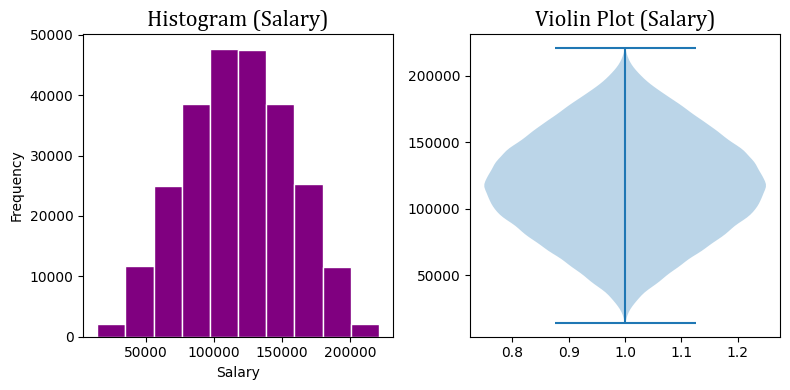

In [25]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(df["salary"], color='purple',bins=10,edgecolor='white')
plt.title("Histogram (Salary)",fontname='cambria',fontsize=16)
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.violinplot(df["salary"])
plt.title("Violin Plot (Salary)",fontname='cambria',fontsize=16)
plt.tight_layout()
plt.show()

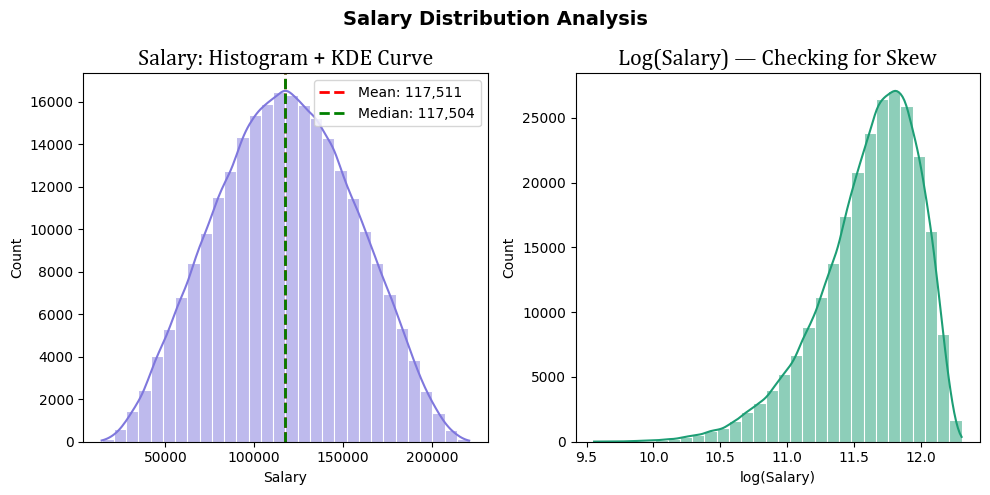

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Salary Distribution Analysis", fontsize=14, fontweight="bold")
sns.histplot(df["salary"], bins=30, kde=True, color="#7F77DD", ax=axes[0], edgecolor="white")
axes[0].set_title("Salary: Histogram + KDE Curve",fontname='cambria',fontsize=16)
axes[0].set_xlabel("Salary")
axes[0].set_ylabel("Count")
axes[0].axvline(df["salary"].mean(), color="red", linestyle="--", linewidth=2,
                label=f"Mean: {df['salary'].mean():,.0f}")
axes[0].axvline(df["salary"].median(), color="green", linestyle="--", linewidth=2,
                label=f"Median: {df['salary'].median():,.0f}")
axes[0].legend()

sns.histplot(np.log(df["salary"]), bins=30, kde=True, color="#1D9E75", ax=axes[1], edgecolor="white")
axes[1].set_title("Log(Salary) — Checking for Skew",fontname='cambria',fontsize=16)
axes[1].set_xlabel("log(Salary)")

plt.tight_layout()
plt.show()


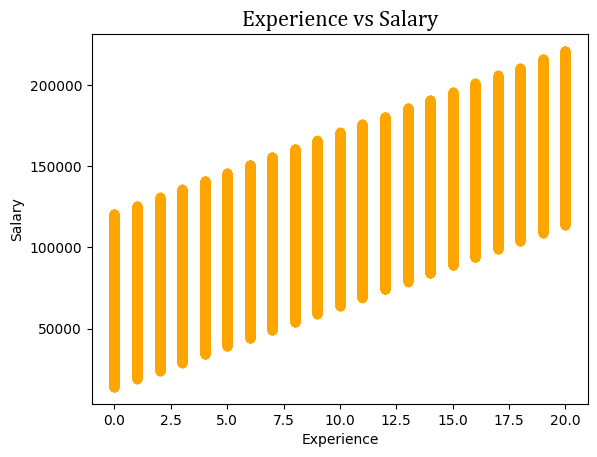

In [27]:
plt.figure()
plt.scatter(df["experience_years"], df["salary"],c='orange')
plt.title("Experience vs Salary",fontname='cambria',fontsize=16)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

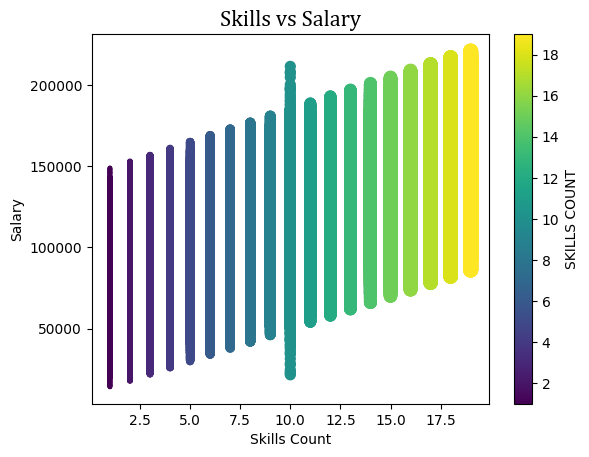

In [28]:
plt.figure()
plt.scatter(df["skills_count"], df["salary"],s=df['skills_count']*5,c=df['skills_count'],cmap='viridis')
plt.colorbar(label='SKILLS COUNT')
plt.xlabel("Skills Count")
plt.ylabel("Salary")
plt.title("Skills vs Salary",fontname='cambria',fontsize=16)
plt.show()

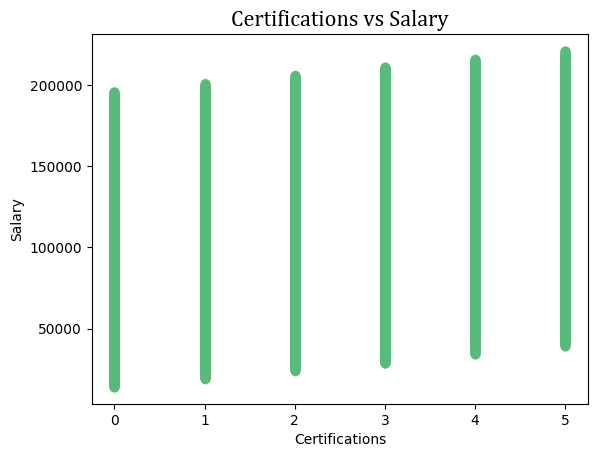

In [29]:
plt.figure()
plt.scatter(df["certifications"], df["salary"],c='#57bb7a',alpha=0.5)
plt.xlabel("Certifications")
plt.ylabel("Salary")
plt.title("Certifications vs Salary",fontname='cambria',fontsize=16)
plt.show()

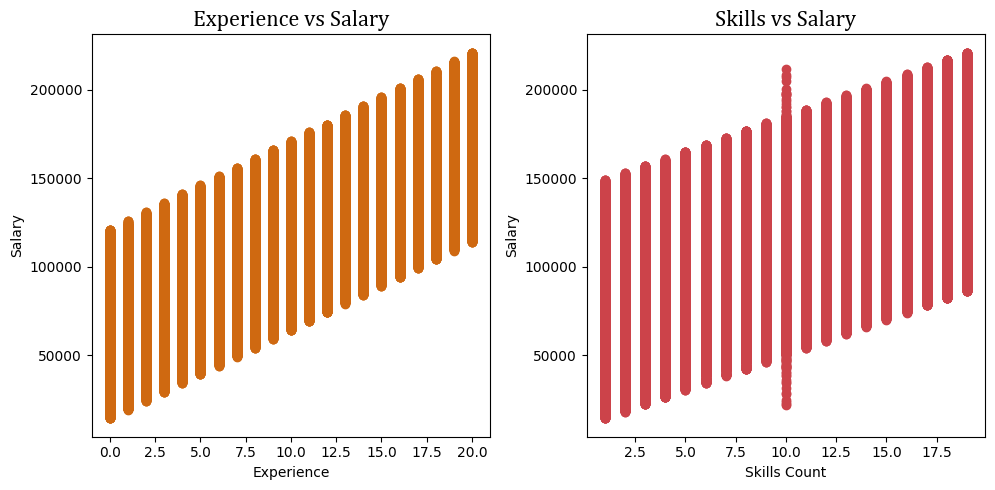

In [30]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(df["experience_years"], df["salary"],color='#cf6911')
plt.title("Experience vs Salary",fontname='cambria',fontsize=16)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.subplot(1, 3, 2)
plt.scatter(df["skills_count"], df["salary"],color='#cc434a')
plt.title("Skills vs Salary",fontname='cambria',fontsize=16)
plt.xlabel("Skills Count")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

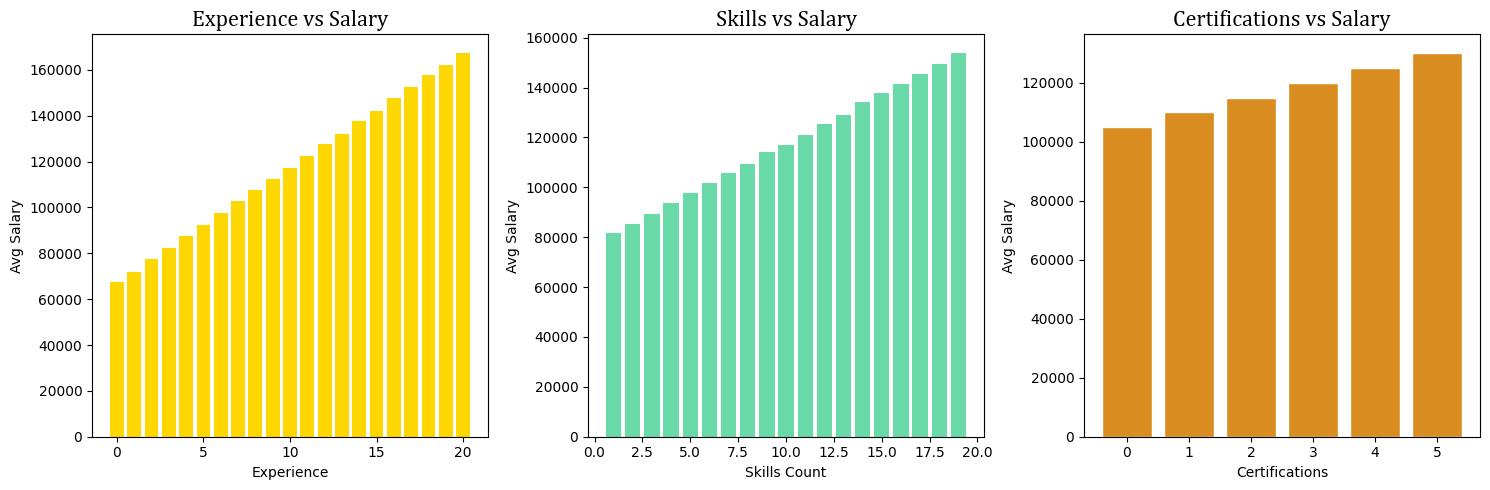

In [31]:
plt.figure(figsize=(15, 5))
exp_salary = df.groupby("experience_years")["salary"].mean()
plt.subplot(1, 3, 1)
plt.bar(exp_salary.index, exp_salary.values,color='#FFD700')
plt.title("Experience vs Salary",fontname='cambria',fontsize=16)
plt.xlabel("Experience")
plt.ylabel("Avg Salary")
skill_salary = df.groupby("skills_count")["salary"].mean()
plt.subplot(1, 3, 2)
plt.bar(skill_salary.index, skill_salary.values,color='#69d9a8')
plt.title("Skills vs Salary",fontname='cambria',fontsize=16)
plt.xlabel("Skills Count")
plt.ylabel("Avg Salary")
cert_salary = df.groupby("certifications")["salary"].mean()
plt.subplot(1, 3, 3)
plt.bar(cert_salary.index, cert_salary.values,color='#d98c1f',edgecolor='white')
plt.title("Certifications vs Salary",fontname='cambria',fontsize=16)
plt.xlabel("Certifications")
plt.ylabel("Avg Salary")

plt.tight_layout()
plt.show()

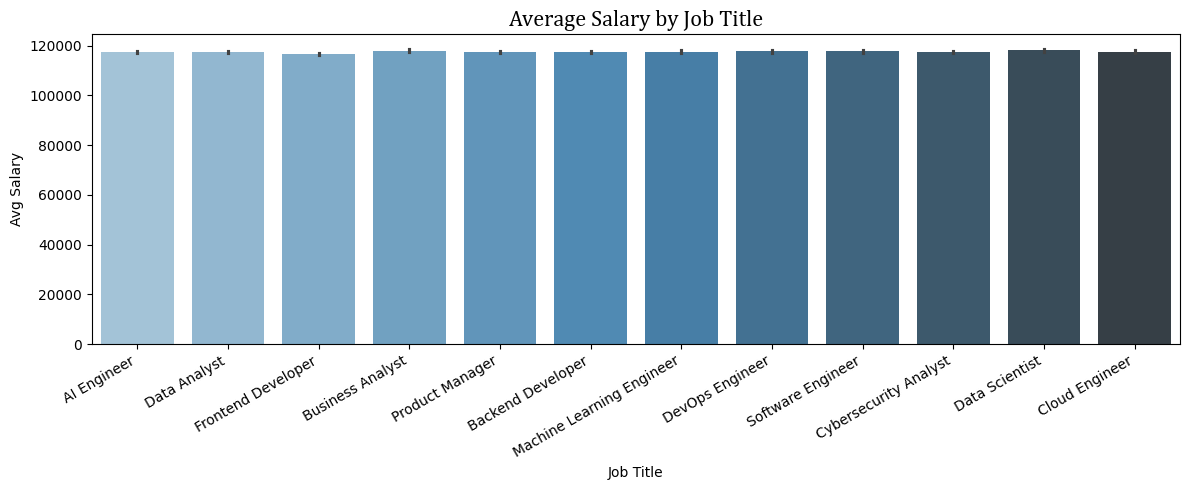

In [32]:
job_salary = df.groupby("job_title")["salary"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x="job_title", y="salary", data=df, palette="Blues_d",hue="job_title")
plt.title("Average Salary by Job Title",fontname='cambria',fontsize=16)
plt.xlabel("Job Title")
plt.ylabel("Avg Salary")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

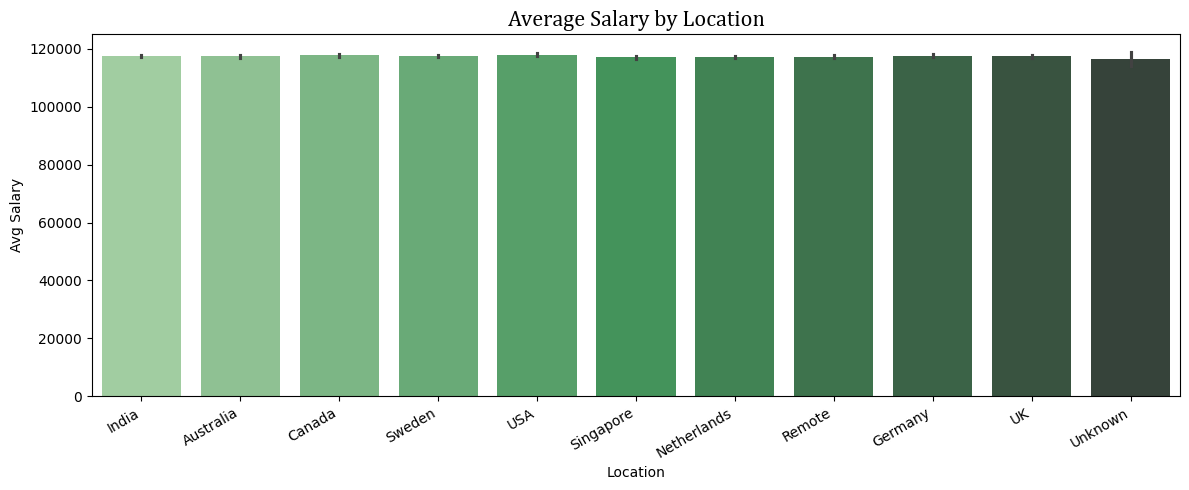

In [33]:
loc_salary = df.groupby("location")["salary"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x="location",y="salary",data=df,palette="Greens_d",hue="location")
plt.title("Average Salary by Location",fontname='cambria',fontsize=16)
plt.xlabel("Location")
plt.ylabel("Avg Salary")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

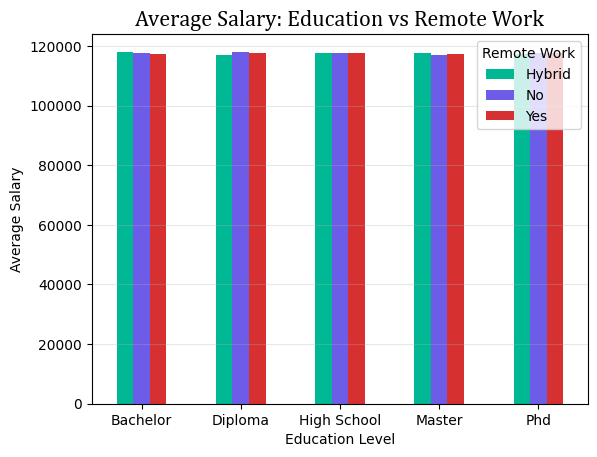

In [34]:
pivot = df.groupby(['education_level','remote_work'])['salary'].mean().unstack()
colors = ['#00b894', '#6c5ce7', '#d63031']
pivot.plot(kind='bar', color=colors)
plt.title("Average Salary: Education vs Remote Work",fontname='cambria',fontsize=16)
plt.xlabel("Education Level")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)
plt.legend(title="Remote Work")
plt.grid(axis='y', alpha=0.3)
plt.show()

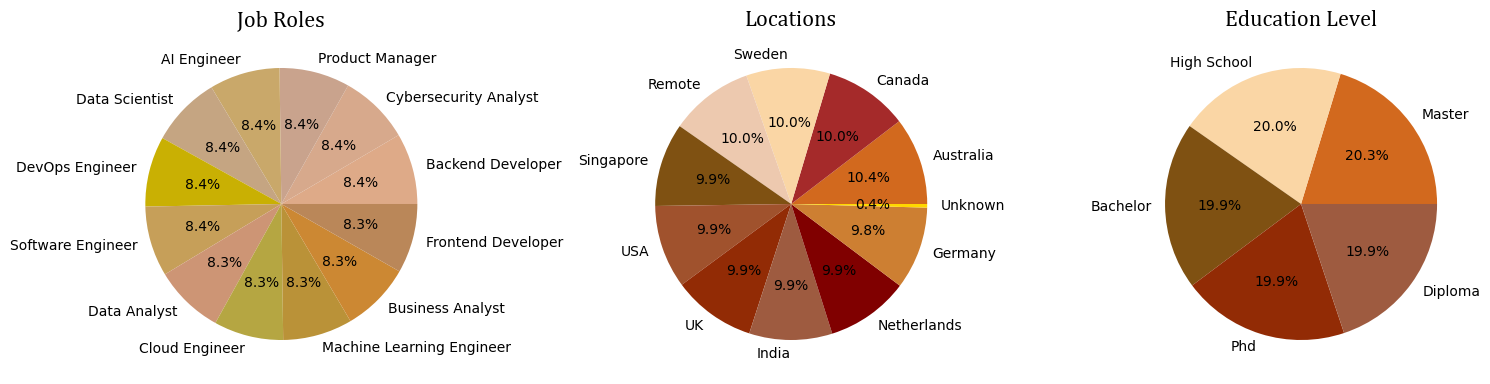

In [35]:
plt.figure(figsize=(15, 5))
job_counts = df["job_title"].value_counts()
plt.subplot(1, 3, 1)
plt.pie(job_counts, labels=job_counts.index, autopct="%1.1f%%",
colors=['#DEAA88','#D7A98C','#C9A38D','#C9A86A','#C5A582','#C9B003','#C69F59','#CD9575','#B5A642','#BA9238','#CC8833','#BA8759'])
plt.title("Job Roles",fontname='cambria',fontsize=16)
location_counts = df["location"].value_counts()
plt.subplot(1, 3, 2)
plt.pie(location_counts, labels=location_counts.index, autopct="%1.1f%%",
colors=['#D2691E','#A52A2A','#FAD6A5','#EDC9AF','#7F5112','#A0522D','#922B05','#9E5B40','#800000','#CD7F32','#FFD700'])  
plt.title("Locations",fontname='cambria',fontsize=16)
edu_counts = df["education_level"].value_counts()
plt.subplot(1, 3, 3)
plt.pie(edu_counts, labels=edu_counts.index, autopct="%1.1f%%",
colors=['#D2691E','#FAD6A5','#7F5112','#922B05','#9E5B40'])
plt.title("Education Level",fontname='cambria',fontsize=16)
plt.tight_layout()
plt.show()

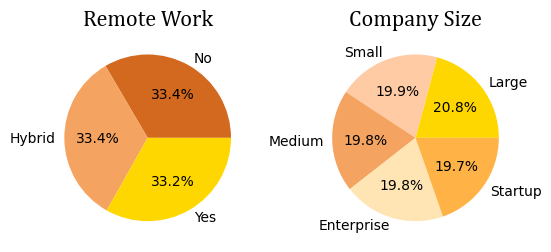

In [36]:
plt.figure(figsize=(8, 5))
remote_counts = df["remote_work"].value_counts()
plt.subplot(1, 3, 2)
plt.pie(remote_counts, labels=remote_counts.index, autopct="%1.1f%%",
colors = ['#D2691E', '#F4A460', '#FFD700'])
plt.title("Remote Work",fontname='cambria',fontsize=16)
company_counts = df["company_size"].value_counts()
plt.subplot(1, 3, 3)
plt.pie(company_counts, labels=company_counts.index, autopct="%1.1f%%",
colors = ['#FFD700', '#FFCBA4', '#F4A460', '#FFE5B4', '#FFB347'])
plt.title("Company Size",fontname='cambria',fontsize=16)
plt.tight_layout()
plt.show()

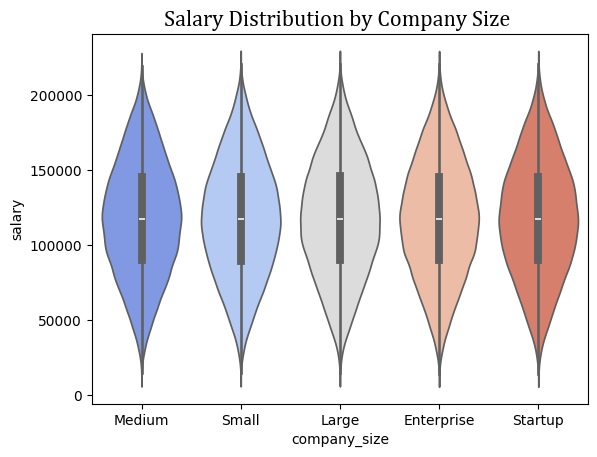

In [37]:
sns.violinplot(x='company_size',y='salary',hue='company_size',data=df,palette='coolwarm',inner='box')
plt.title("Salary Distribution by Company Size ",fontname='cambria',fontsize=16)
plt.show()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Bachelor'),
  Text(1, 0, 'Phd'),
  Text(2, 0, 'High School'),
  Text(3, 0, 'Diploma'),
  Text(4, 0, 'Master')])

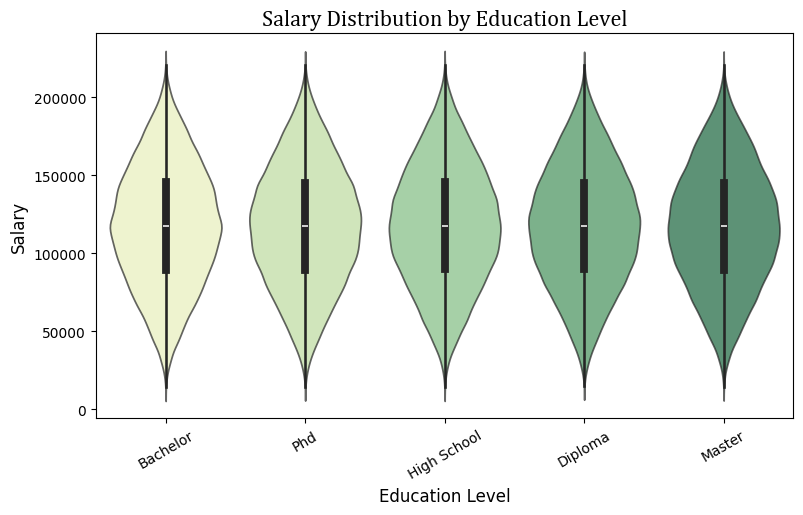

In [38]:
plt.figure(figsize=(9,5))
sns.violinplot(x="education_level",y="salary",hue='education_level',data=df,palette="YlGn",alpha=0.7)
plt.title("Salary Distribution by Education Level",fontname='cambria',fontsize=16)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Salary", fontsize=12)
plt.xticks(rotation=30)

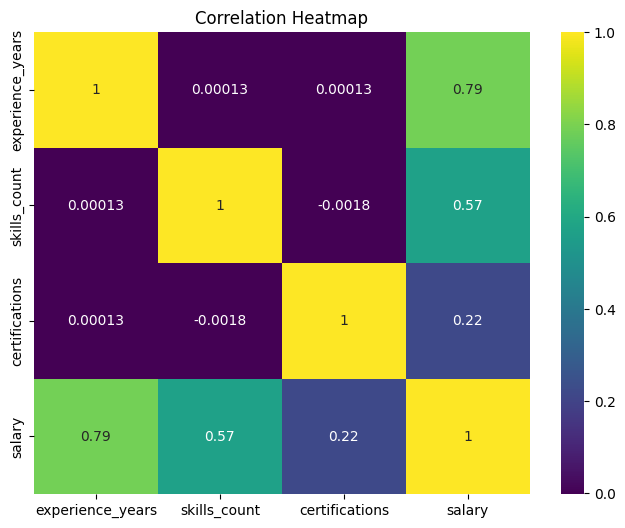

In [39]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True,cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()

In [40]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,85270
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,103860
2,Frontend Developer,18,Phd,4,Media,Large,Australia,No,1,126390
3,Business Analyst,19,Phd,13,Retail,Medium,Canada,Yes,0,162191
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,Phd,2,Telecom,Enterprise,India,No,1,115590
249996,Frontend Developer,20,Phd,7,Telecom,Startup,Remote,No,2,152738
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,69923
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,46351


In [41]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# COPY DATAFRAME
# =========================
df = df.copy()

# =========================
# REDUCE DATA SIZE
# =========================
df = df.sample(n=50000, random_state=42)

# =========================
# FEATURE ENGINEERING
# =========================
df['exp_squared'] = df['experience_years'] ** 2

df['skill_per_exp'] = (
    df['skills_count'] / (df['experience_years'] + 1)
)

df['cert_per_skill'] = (
    df['certifications'] / (df['skills_count'] + 1)
)

# =========================
# CREATE SENIORITY COLUMN
# =========================
df['seniority'] = pd.cut(
    df['experience_years'],
    bins=[0, 2, 5, 10, 20],
    labels=['Fresher', 'Junior', 'Mid', 'Senior']
).astype(str)

# =========================
# REMOVE INTERVAL COLUMN
# =========================
if 'salary_range' in df.columns:
    df.drop('salary_range', axis=1, inplace=True)

# =========================
# ENCODING
# =========================
cat_cols = [
    'job_title',
    'education_level',
    'location',
    'industry',
    'company_size',
    'remote_work',
    'seniority'
]

# keep only existing columns
cat_cols = [col for col in cat_cols if col in df.columns]

df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

# =========================
# CONVERT BOOL TO INT
# =========================
bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    df[col] = df[col].astype(int)

# =========================
# REMOVE NULL VALUES
# =========================
df.dropna(inplace=True)

# =========================
# FEATURES & TARGET
# =========================
X = df.drop('salary', axis=1)
y = df['salary']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# SCALING
# =========================
num_cols = [
    'experience_years',
    'skills_count',
    'certifications',
    'exp_squared',
    'skill_per_exp',
    'cert_per_skill'
]

# keep only available numeric columns
num_cols = [col for col in num_cols if col in X_train.columns]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# =========================
# CHECK DATA TYPES
# =========================
print(X_train.dtypes.unique())

# =========================
# TRAIN MODEL
# =========================
knn = KNeighborsRegressor(n_neighbors=7)

knn.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================
y_pred = knn.predict(X_test)

# =========================
# EVALUATION
# =========================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n🔹 MODEL PERFORMANCE")
print("R2 Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)

# =========================
# SAVE MODEL
# =========================
pickle.dump(knn, open("knn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("\n✅ Model ready for deployment!")

[dtype('float64') dtype('int64')]

🔹 MODEL PERFORMANCE
R2 Score : 0.9551209931110425
MAE      : 6445.762085714286
MSE      : 65774772.42001633

✅ Model ready for deployment!
